In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [3]:
print(nav.shape)
print(performance.shape)

nav.head()

(46000, 3)
(40, 19)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
print(nav.shape)
print(performance.shape)

nav.head()

(46000, 3)
(40, 19)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

In [6]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [7]:
volatility = nav.groupby(
    "amfi_code"
)["daily_return"].std() * np.sqrt(252)

volatility = volatility.reset_index()

volatility.columns = [
    "amfi_code",
    "annual_volatility"
]

volatility.head()

,amfi_code,annual_volatility
0,100016,0.145481
1,100025,0.039052
2,100033,0.189367
3,101206,0.145682
4,101207,0.257973


In [8]:
metrics = performance.merge(
    volatility,
    on="amfi_code"
)

metrics.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,annual_volatility
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,0.137414
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.139394
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,0.251406
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,0.249501
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,0.039671


In [9]:
sharpe_rank = metrics[
    ["scheme_name","sharpe_ratio"]
].sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [10]:
sharpe_rank.to_csv(
    "../data/processed/fund_sharpe_ranks.csv",
    index=False
)

print("Saved")

Saved


In [11]:
alpha_beta = metrics[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [12]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta_table.csv",
    index=False
)

print("Saved")

Saved


In [13]:
var_table = nav.groupby(
    "amfi_code"
)["daily_return"].quantile(
    0.05
)

var_table = var_table.reset_index()

var_table.columns = [
    "amfi_code",
    "VaR_95"
]

var_table.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [14]:
drawdown_list = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["cummax"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"]
        - temp["cummax"]
    ) / temp["cummax"]

    max_dd = temp["drawdown"].min()

    drawdown_list.append(
        [code,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
risk_table = var_table.merge(
    drawdown_df,
    on="amfi_code"
)

risk_table.head()

,amfi_code,VaR_95,max_drawdown
0,100016,-0.014364,-0.247344
1,100025,-0.003793,-0.043083
2,100033,-0.019034,-0.162172
3,101206,-0.013282,-0.112916
4,101207,-0.026021,-0.354469


In [16]:
risk_table.to_csv(
    "../data/processed/var_drawdown_summary.csv",
    index=False
)

print("Saved")

Saved


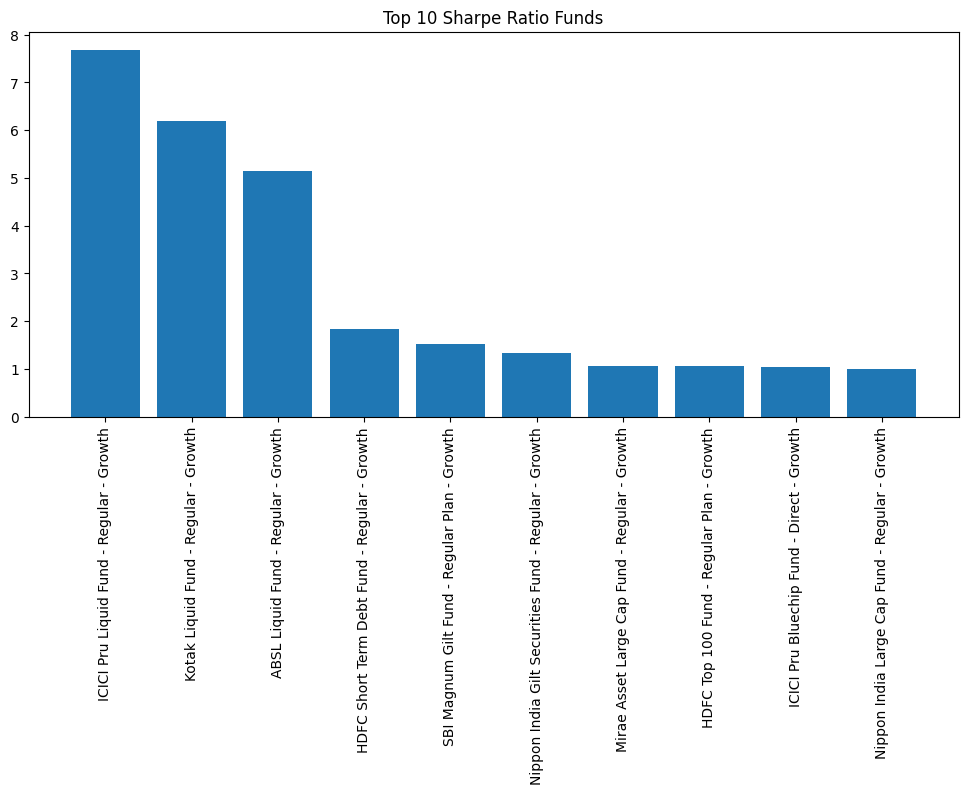

In [17]:
top10 = sharpe_rank.head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top10["scheme_name"],
    top10["sharpe_ratio"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Sharpe Ratio Funds")

plt.show()

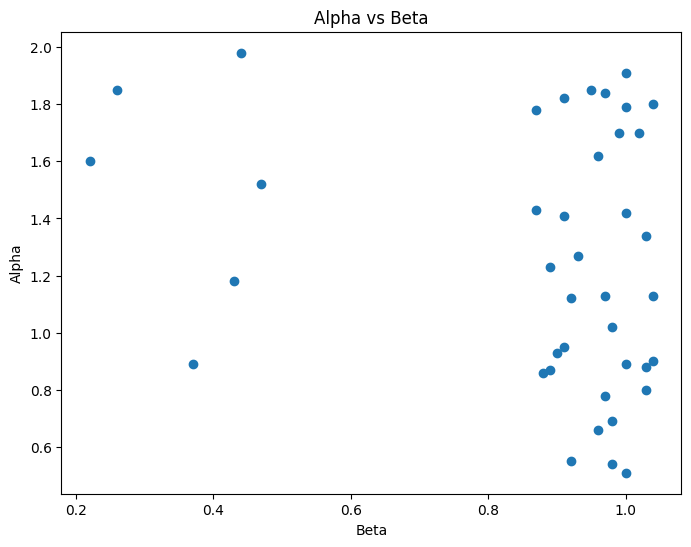

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    metrics["beta"],
    metrics["alpha"]
)

plt.xlabel("Beta")

plt.ylabel("Alpha")

plt.title("Alpha vs Beta")

plt.show()

In [19]:
# Performance Analytics Insights

#1. Top Sharpe Ratio funds delivered the best risk-adjusted returns.
#2. Alpha values indicate excess return over benchmark.
#3. Beta measures fund sensitivity to market movement.
#4. VaR estimates potential downside risk at 95% confidence.
#5. Maximum Drawdown highlights historical worst-case losses.
#6. Risk and return vary significantly across categories.